In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns

In [2]:
df=sns.load_dataset('iris')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df=df[df['species'] !=0][['sepal_width','petal_width','species']]

In [8]:
df.head()

,sepal_width,petal_width,species
50,3.2,1.4,1
51,3.2,1.5,1
52,3.1,1.5,1
53,2.3,1.3,1
54,2.8,1.5,1


In [9]:
import matplotlib.pyplot as plt

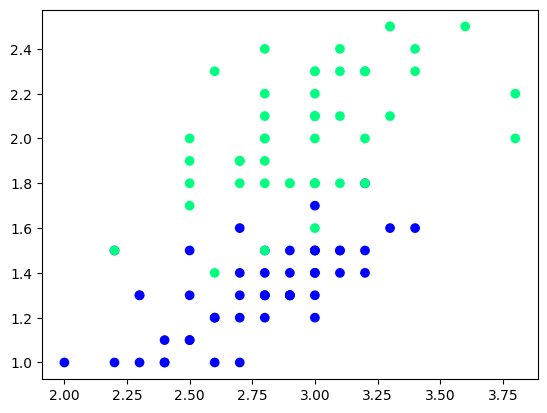

In [10]:
plt.scatter(df['sepal_width'],df['petal_width'],c=df['species'],cmap='winter')

In [11]:
df_train=df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_width,species
95,3.0,1.2,1
104,3.0,2.2,2
58,2.9,1.3,1
89,2.5,1.3,1
59,2.7,1.4,1
67,2.7,1.0,1
63,2.9,1.4,1
82,2.7,1.2,1
99,2.8,1.3,1
77,3.0,1.7,1


In [12]:
# taking only 10 rows for training
df=df.sample(100)
df_train=df.iloc[:60,:].sample(10)
df_val=df.iloc[60:80,:].sample(5)
df_test=df.iloc[80:,:].sample(5)

In [13]:
df_train

,sepal_width,petal_width,species
80,2.4,1.1,1
62,2.2,1.0,1
87,2.3,1.3,1
85,3.4,1.6,1
99,2.8,1.3,1
117,3.8,2.2,2
54,2.8,1.5,1
64,2.9,1.3,1
65,3.1,1.4,1
111,2.7,1.9,2


In [14]:
df_val

,sepal_width,petal_width,species
74,2.9,1.3,1
143,3.2,2.3,2
145,3.0,2.3,2
96,2.9,1.3,1
91,3.0,1.4,1


In [15]:
df_test

,sepal_width,petal_width,species
141,3.1,2.3,2
131,3.8,2.0,2
128,2.8,2.1,2
138,3.0,1.8,2
86,3.1,1.5,1


In [16]:
X_test=df.iloc[:,0:2].values
y_test=df.iloc[:,-1].values

# CASE -1 Bagging

In [17]:
# data for tree 1
df_bag=df_train.sample(8,replace=True)
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_width,species
80,2.4,1.1,1
87,2.3,1.3,1
117,3.8,2.2,2
80,2.4,1.1,1
54,2.8,1.5,1
65,3.1,1.4,1
54,2.8,1.5,1
85,3.4,1.6,1


In [26]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
# !pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)


In [47]:

dt_bag1 = DecisionTreeClassifier()

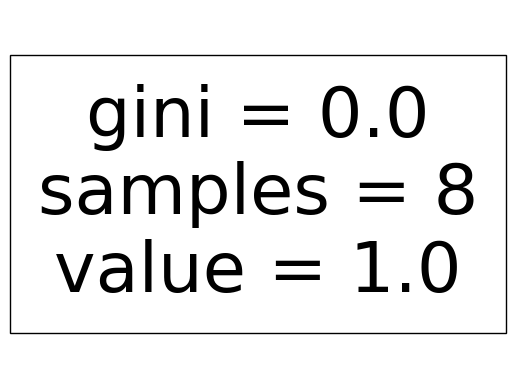

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.5


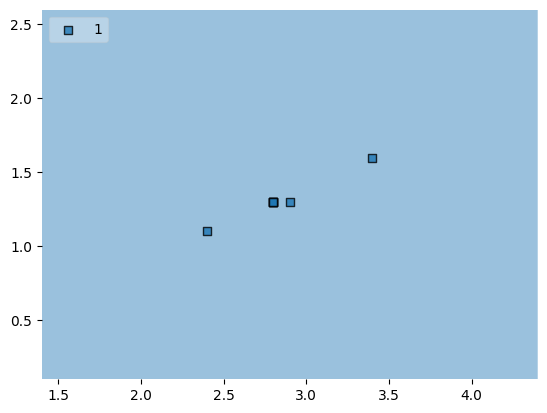

In [48]:
evaluate(dt_bag1,X,y)

In [29]:
# Data for tree 1
df_bag=df_train.sample(8,replace=True)

In [30]:
# fetch X and y
X=df_bag.iloc[:,0:2]
y=df_bag.iloc[:,-1]
df_bag

,sepal_width,petal_width,species
87,2.3,1.3,1
65,3.1,1.4,1
117,3.8,2.2,2
62,2.2,1.0,1
85,3.4,1.6,1
62,2.2,1.0,1
87,2.3,1.3,1
65,3.1,1.4,1


In [42]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

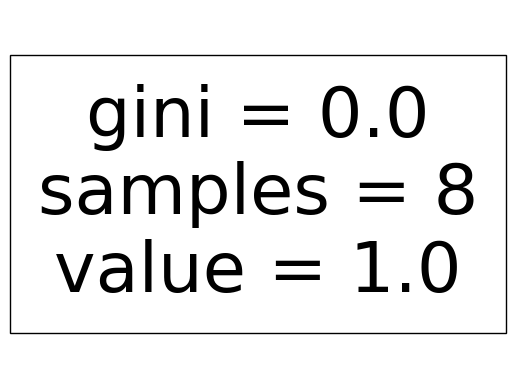

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.5


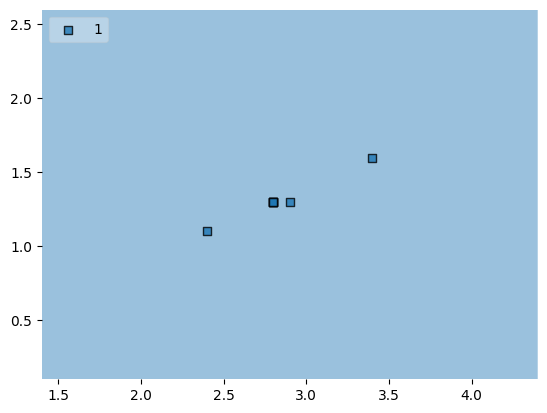

In [43]:
evaluate(dt_bag2,X,y)

In [40]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_width,species
99,2.8,1.3,1
64,2.9,1.3,1
80,2.4,1.1,1
99,2.8,1.3,1
99,2.8,1.3,1
85,3.4,1.6,1
99,2.8,1.3,1
99,2.8,1.3,1


In [49]:
df_test

,sepal_width,petal_width,species
141,3.1,2.3,2
131,3.8,2.0,2
128,2.8,2.1,2
138,3.0,1.8,2
86,3.1,1.5,1


In [51]:

print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))


Predictor 1 [1]
Predictor 2 [1]


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [52]:

# Row sampling without replacement
df_train

,sepal_width,petal_width,species
80,2.4,1.1,1
62,2.2,1.0,1
87,2.3,1.3,1
85,3.4,1.6,1
99,2.8,1.3,1
117,3.8,2.2,2
54,2.8,1.5,1
64,2.9,1.3,1
65,3.1,1.4,1
111,2.7,1.9,2


In [53]:

df_train.sample(8)

,sepal_width,petal_width,species
117,3.8,2.2,2
64,2.9,1.3,1
65,3.1,1.4,1
99,2.8,1.3,1
111,2.7,1.9,2
85,3.4,1.6,1
87,2.3,1.3,1
54,2.8,1.5,1
